# Phase 0 — Exploratory Data Analysis

RSNA 2026 Knee Abnormality Detection · macro ROC-AUC across 12 multilabel targets.

**Source notebook** — edit here, then sync to Kaggle: `python scripts/sync_kaggle_eda.py --push`

**Run on Kaggle** with the competition data attached for meaningful results. Locally, use synthetic sample data (`python scripts/create_sample_data.py`) to verify the notebook runs end-to-end.

This notebook answers the Phase 0 questions:
1. Label prevalence and class imbalance
2. Label co-occurrence patterns
3. Series structure per study (`FluidSensitiveSeries`)
4. Radiology report characteristics (train only)
5. Train vs. test distribution shifts
6. DICOM geometry (slice counts, spatial size) on a sample

## Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve repo root when running locally from notebooks/
for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / "src" / "rsna_knee").is_dir():
        REPO_ROOT = candidate
        break
else:
    REPO_ROOT = Path.cwd().parent

src_path = str(REPO_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from rsna_knee.constants import (
    FLUID_COL,
    PATIENT_SEX_COL,
    REPORT_COL,
    SERIES_ID_COL,
    STUDY_ID_COL,
    TARGET_DISPLAY_NAMES,
    TARGET_LABELS,
)
from rsna_knee.data.dicom_io import load_series_volume, series_metadata_summary
from rsna_knee.utils.paths import (
    default_data_root,
    is_kaggle_kernel,
    series_dir,
)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

DATA_ROOT = default_data_root()
RNG = np.random.default_rng(42)

print(f"Environment : {'Kaggle kernel' if is_kaggle_kernel() else 'local'}")
print(f"Data root   : {DATA_ROOT}")

Environment : local
Data root   : C:\SBX\Kaggle\RSNA_knee_abnormality_detection\data\sample


In [2]:
from rsna_knee.data.schema import (
    load_test_series_table,
    load_test_table,
    load_train_series_table,
    load_train_table,
)

train = load_train_table(DATA_ROOT)
train_series = load_train_series_table(DATA_ROOT)
test = load_test_table(DATA_ROOT)
test_series = load_test_series_table(DATA_ROOT)

print(f"Train studies : {len(train):,}")
print(f"Train series  : {len(train_series):,}")
print(f"Test studies  : {len(test):,}")
print(f"Test series   : {len(test_series):,}")

Train studies : 4
Train series  : 8
Test studies  : 2
Test series   : 4


## 1. Dataset overview

In [3]:
display(train.head(3))
display(train_series.head(3))

,StudyInstanceUID,PatientSex,Report,acl_tear,mcl_tear,medial_meniscus_injury,lateral_meniscus_injury,medial_osteoarthritis,lateral_osteoarthritis,patellofemoral_osteoarthritis,joint_effusion,synovitis,bakers_cyst,bone_contusion,fracture
0,1.2.826.0.1.3680043.8.498.74992240091738627898...,F,Sample radiology report for local testing.,1,0,1,0,0,1,1,1,0,0,0,1
1,1.2.826.0.1.3680043.8.498.84899869291664506482...,F,Sample radiology report for local testing.,1,0,0,0,0,1,0,1,0,1,1,1
2,1.2.826.0.1.3680043.8.498.66066799257872525288...,F,Sample radiology report for local testing.,0,0,0,0,0,1,1,0,0,0,0,0


,StudyInstanceUID,SeriesInstanceUID,FluidSensitiveSeries
0,1.2.826.0.1.3680043.8.498.74992240091738627898...,1.2.826.0.1.3680043.8.498.23785470585143409420...,1
1,1.2.826.0.1.3680043.8.498.74992240091738627898...,1.2.826.0.1.3680043.8.498.30413226022252036336...,0
2,1.2.826.0.1.3680043.8.498.84899869291664506482...,1.2.826.0.1.3680043.8.498.22427936274305366292...,1


In [4]:
overview = pd.DataFrame(
    {
        "train_studies": [len(train)],
        "train_series": [len(train_series)],
        "test_studies": [len(test)],
        "test_series": [len(test_series)],
        "series_per_study_train_mean": [train_series.groupby(STUDY_ID_COL).size().mean()],
        "series_per_study_test_mean": [test_series.groupby(STUDY_ID_COL).size().mean()],
        "unique_patients_train_sex": [train[PATIENT_SEX_COL].nunique() if PATIENT_SEX_COL in train else np.nan],
    }
)
overview

,train_studies,train_series,test_studies,test_series,series_per_study_train_mean,series_per_study_test_mean,unique_patients_train_sex
0,4,8,2,4,2.000,2.000,2


In [5]:
missing = pd.DataFrame(
    {
        "train_missing": train.isna().sum(),
        "train_series_missing": train_series.isna().sum(),
        "test_missing": test.isna().sum(),
        "test_series_missing": test_series.isna().sum(),
    }
)
missing[missing.sum(axis=1) > 0]

,train_missing,train_series_missing,test_missing,test_series_missing


## 2. Label prevalence

Macro ROC-AUC treats every label equally — rare findings still matter.

In [6]:
label_stats = []
for label in TARGET_LABELS:
    positives = int(train[label].sum())
    total = len(train)
    label_stats.append(
        {
            "label": label,
            "display_name": TARGET_DISPLAY_NAMES[label],
            "positives": positives,
            "negatives": total - positives,
            "positive_rate": positives / total,
            "prevalence_pct": 100 * positives / total,
        }
    )

label_df = pd.DataFrame(label_stats).sort_values("positive_rate", ascending=False)
label_df

,label,display_name,positives,negatives,positive_rate,prevalence_pct
6,patellofemoral_osteoarthritis,Patellofemoral Osteoarthritis,3,1,0.750,75.000
7,joint_effusion,Joint Effusion,3,1,0.750,75.000
5,lateral_osteoarthritis,Lateral Osteoarthritis,3,1,0.750,75.000
0,acl_tear,ACL Tear,2,2,0.500,50.000
11,fracture,Fracture,2,2,0.500,50.000
4,medial_osteoarthritis,Medial Osteoarthritis,1,3,0.250,25.000
2,medial_meniscus_injury,Medial Meniscus Injury,1,3,0.250,25.000
3,lateral_meniscus_injury,Lateral Meniscus Injury,1,3,0.250,25.000
10,bone_contusion,Bone Contusion,1,3,0.250,25.000
9,bakers_cyst,Baker's Cyst,1,3,0.250,25.000


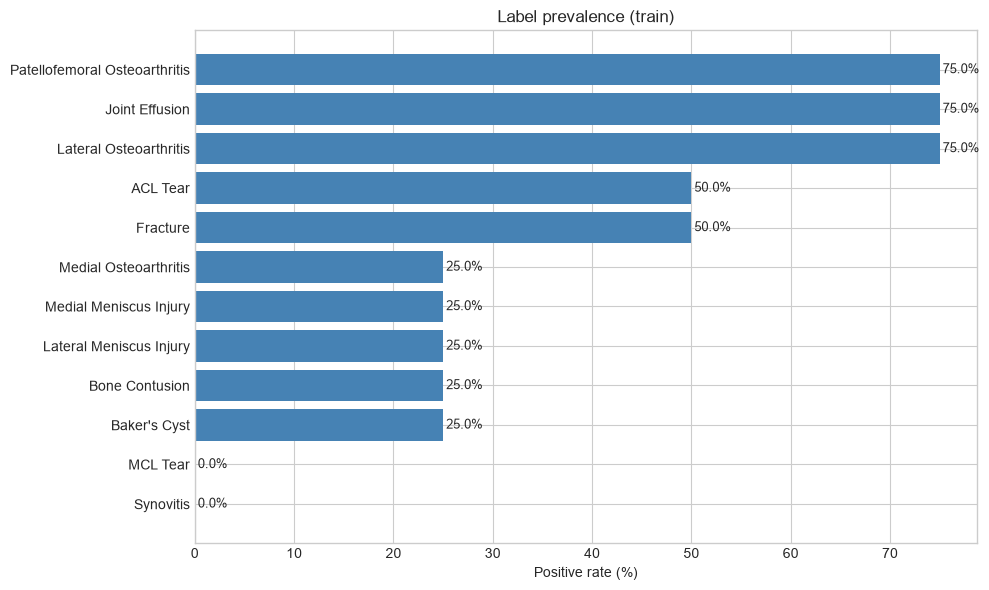

Labels per study — mean: 4.50, median: 5, max: 6
Studies with zero positive labels: 0


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(label_df["display_name"], label_df["prevalence_pct"], color="steelblue")
ax.set_xlabel("Positive rate (%)")
ax.set_title("Label prevalence (train)")
ax.invert_yaxis()

for bar, rate in zip(bars, label_df["prevalence_pct"], strict=True):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2, f"{rate:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

labels_per_study = train[TARGET_LABELS].sum(axis=1)
print("Labels per study — mean: {:.2f}, median: {:.0f}, max: {:.0f}".format(
    labels_per_study.mean(), labels_per_study.median(), labels_per_study.max()
))
print("Studies with zero positive labels:", int((labels_per_study == 0).sum()))

## 3. Label co-occurrence

Joint positive rate: fraction of studies where both labels are positive.

In [8]:
y = train[TARGET_LABELS].to_numpy(dtype=float)
n = len(train)
cooccur = (y.T @ y) / n

cooccur_df = pd.DataFrame(cooccur, index=TARGET_LABELS, columns=TARGET_LABELS)
cooccur_df

,acl_tear,mcl_tear,medial_meniscus_injury,lateral_meniscus_injury,medial_osteoarthritis,lateral_osteoarthritis,patellofemoral_osteoarthritis,joint_effusion,synovitis,bakers_cyst,bone_contusion,fracture
acl_tear,0.500,0.000,0.250,0.000,0.000,0.500,0.250,0.500,0.000,0.250,0.250,0.500
mcl_tear,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
medial_meniscus_injury,0.250,0.000,0.250,0.000,0.000,0.250,0.250,0.250,0.000,0.000,0.000,0.250
lateral_meniscus_injury,0.000,0.000,0.000,0.250,0.250,0.000,0.250,0.250,0.000,0.000,0.000,0.000
medial_osteoarthritis,0.000,0.000,0.000,0.250,0.250,0.000,0.250,0.250,0.000,0.000,0.000,0.000
lateral_osteoarthritis,0.500,0.000,0.250,0.000,0.000,0.750,0.500,0.500,0.000,0.250,0.250,0.500
patellofemoral_osteoarthritis,0.250,0.000,0.250,0.250,0.250,0.500,0.750,0.500,0.000,0.000,0.000,0.250
joint_effusion,0.500,0.000,0.250,0.250,0.250,0.500,0.500,0.750,0.000,0.250,0.250,0.500
synovitis,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
bakers_cyst,0.250,0.000,0.000,0.000,0.000,0.250,0.000,0.250,0.000,0.250,0.250,0.250


C:\Users\marie\AppData\Local\Temp\ipykernel_24140\3745207918.py:7: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  plt.tight_layout()
c:\SBX\Kaggle\RSNA_knee_abnormality_detection\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


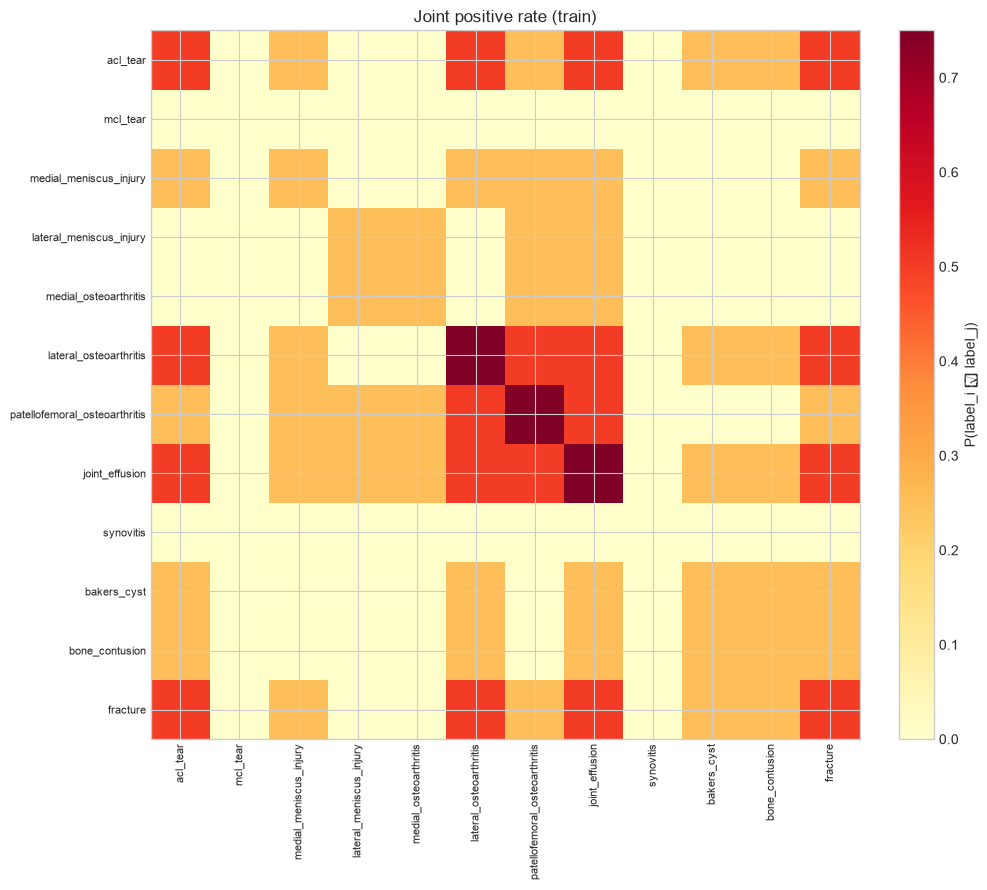

In [9]:
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cooccur_df.values, cmap="YlOrRd", vmin=0, vmax=cooccur_df.values.max())
ax.set_xticks(range(len(TARGET_LABELS)), TARGET_LABELS, rotation=90, fontsize=8)
ax.set_yticks(range(len(TARGET_LABELS)), TARGET_LABELS, fontsize=8)
ax.set_title("Joint positive rate (train)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="P(label_i ∧ label_j)")
plt.tight_layout()
plt.show()

In [10]:
# Top co-occurring pairs (excluding diagonal)
pairs = []
for i, a in enumerate(TARGET_LABELS):
    for j, b in enumerate(TARGET_LABELS):
        if j <= i:
            continue
        pairs.append({"label_a": a, "label_b": b, "joint_rate": cooccur[i, j]})

top_pairs = pd.DataFrame(pairs).sort_values("joint_rate", ascending=False).head(10)
top_pairs

,label_a,label_b,joint_rate
6,acl_tear,joint_effusion,0.500
4,acl_tear,lateral_osteoarthritis,0.500
50,lateral_osteoarthritis,fracture,0.500
51,patellofemoral_osteoarthritis,joint_effusion,0.500
10,acl_tear,fracture,0.500
59,joint_effusion,fracture,0.500
45,lateral_osteoarthritis,patellofemoral_osteoarthritis,0.500
46,lateral_osteoarthritis,joint_effusion,0.500
39,medial_osteoarthritis,patellofemoral_osteoarthritis,0.250
1,acl_tear,medial_meniscus_injury,0.250


## 4. Series structure per study

Each study may contain multiple MRI sequences. `FluidSensitiveSeries == 1` marks PD/STIR-like sequences useful for soft-tissue findings.

In [11]:
series_per_study = train_series.groupby(STUDY_ID_COL).size().rename("num_series")
fluid_per_study = (
    train_series.groupby(STUDY_ID_COL)[FLUID_COL].sum().rename("num_fluid_sensitive")
    if FLUID_COL in train_series.columns
    else pd.Series(dtype=float)
)

series_summary = pd.concat([series_per_study, fluid_per_study], axis=1)
series_summary.describe()

,num_series,num_fluid_sensitive
count,4.000,4.000
mean,2.000,1.000
std,0.000,0.000
min,2.000,1.000
25%,2.000,1.000
50%,2.000,1.000
75%,2.000,1.000
max,2.000,1.000


Studies with ≥1 fluid-sensitive series: 100.0%


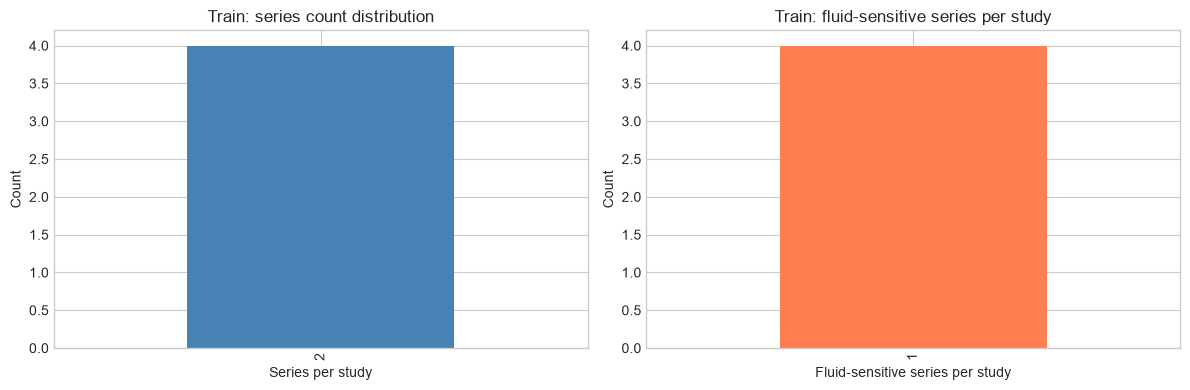

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

series_per_study.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_xlabel("Series per study")
axes[0].set_ylabel("Count")
axes[0].set_title("Train: series count distribution")

if FLUID_COL in train_series.columns:
    fluid_per_study.value_counts().sort_index().plot(kind="bar", ax=axes[1], color="coral")
    axes[1].set_xlabel("Fluid-sensitive series per study")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Train: fluid-sensitive series per study")
    pct_with_fluid = 100 * (fluid_per_study > 0).mean()
    print(f"Studies with ≥1 fluid-sensitive series: {pct_with_fluid:.1f}%")
else:
    axes[1].set_visible(False)

plt.tight_layout()
plt.show()

In [13]:
if FLUID_COL in train_series.columns:
    fluid_rate = train_series[FLUID_COL].mean()
    print(f"Series-level fluid-sensitive rate: {100 * fluid_rate:.1f}%")

    # Label prevalence conditional on having fluid-sensitive series
    studies_with_fluid = set(fluid_per_study[fluid_per_study > 0].index)
    mask = train[STUDY_ID_COL].isin(studies_with_fluid)
    cond_rates = train.loc[mask, TARGET_LABELS].mean().rename("rate_with_fluid")
    base_rates = train[TARGET_LABELS].mean().rename("rate_all")
    pd.concat([base_rates, cond_rates], axis=1)

Series-level fluid-sensitive rate: 50.0%


## 5. Radiology reports (train only)

Reports are **not available at inference**. Use this section to gauge whether text is worth exploiting during training (distillation, auxiliary loss, etc.).

,value
missing_or_empty,0.000
char_mean,42.000
char_median,42.000
char_p95,42.000
word_mean,6.000
word_median,6.000


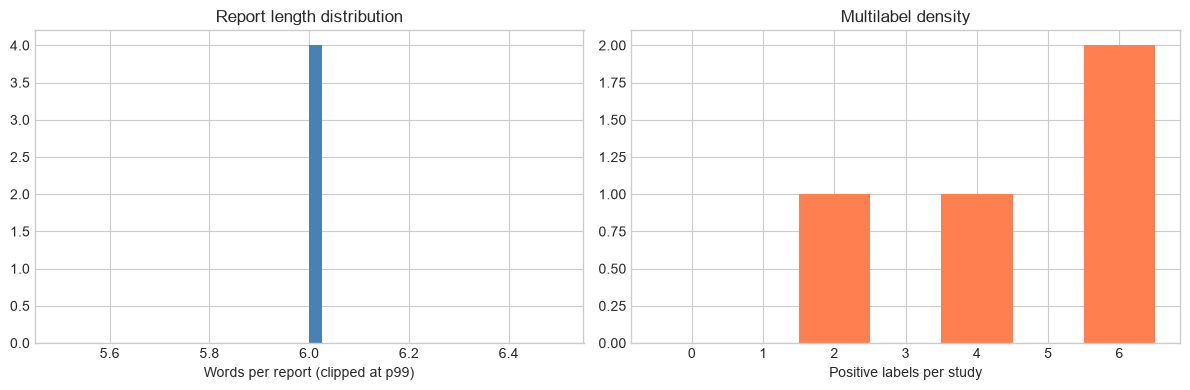

Sample report:
 Sample radiology report for local testing. 


In [14]:
if REPORT_COL in train.columns:
    reports = train[REPORT_COL].fillna("").astype(str)
    report_chars = reports.str.len()
    report_words = reports.str.split().str.len()

    report_stats = pd.Series(
        {
            "missing_or_empty": int((reports.str.strip() == "").sum()),
            "char_mean": report_chars.mean(),
            "char_median": report_chars.median(),
            "char_p95": report_chars.quantile(0.95),
            "word_mean": report_words.mean(),
            "word_median": report_words.median(),
        }
    )
    display(report_stats.to_frame("value"))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    report_words.clip(upper=report_words.quantile(0.99)).hist(bins=40, ax=axes[0], color="steelblue")
    axes[0].set_xlabel("Words per report (clipped at p99)")
    axes[0].set_title("Report length distribution")

    labels_per_study.hist(bins=range(0, int(labels_per_study.max()) + 2), ax=axes[1], color="coral", align="left")
    axes[1].set_xlabel("Positive labels per study")
    axes[1].set_title("Multilabel density")
    plt.tight_layout()
    plt.show()

    print("Sample report:\n", reports.iloc[0][:500], "..." if len(reports.iloc[0]) > 500 else "")
else:
    print("No Report column in train.csv")

## 6. Train vs. test metadata

Check for distribution shifts that could affect generalization. Test labels are hidden during scoring.

In [15]:
compare_rows = []

if PATIENT_SEX_COL in train.columns and PATIENT_SEX_COL in test.columns:
    for sex in sorted(set(train[PATIENT_SEX_COL].dropna()) | set(test[PATIENT_SEX_COL].dropna())):
        compare_rows.append(
            {
                "feature": PATIENT_SEX_COL,
                "value": sex,
                "train_pct": 100 * (train[PATIENT_SEX_COL] == sex).mean(),
                "test_pct": 100 * (test[PATIENT_SEX_COL] == sex).mean(),
            }
        )

train_sps = train_series.groupby(STUDY_ID_COL).size()
test_sps = test_series.groupby(STUDY_ID_COL).size()
compare_rows.append(
    {
        "feature": "series_per_study",
        "value": "mean",
        "train_pct": train_sps.mean(),
        "test_pct": test_sps.mean(),
    }
)
compare_rows.append(
    {
        "feature": "series_per_study",
        "value": "median",
        "train_pct": train_sps.median(),
        "test_pct": test_sps.median(),
    }
)

if FLUID_COL in train_series.columns and FLUID_COL in test_series.columns:
    compare_rows.append(
        {
            "feature": "fluid_sensitive_series_rate",
            "value": "series-level",
            "train_pct": 100 * train_series[FLUID_COL].mean(),
            "test_pct": 100 * test_series[FLUID_COL].mean(),
        }
    )

compare_df = pd.DataFrame(compare_rows)
compare_df["delta"] = compare_df["test_pct"] - compare_df["train_pct"]
compare_df

,feature,value,train_pct,test_pct,delta
0,PatientSex,F,75.000,50.000,-25.000
1,PatientSex,M,25.000,50.000,25.000
2,series_per_study,mean,2.000,2.000,0.000
3,series_per_study,median,2.000,2.000,0.000
4,fluid_sensitive_series_rate,series-level,50.000,50.000,0.000


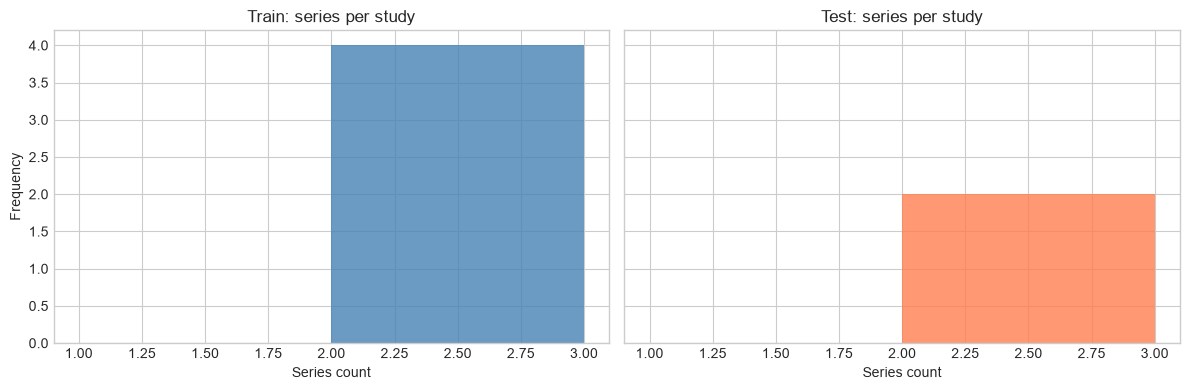

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
train_sps.plot(kind="hist", bins=range(1, int(max(train_sps.max(), test_sps.max())) + 2), ax=axes[0], color="steelblue", alpha=0.8)
axes[0].set_title("Train: series per study")
axes[0].set_xlabel("Series count")

test_sps.plot(kind="hist", bins=range(1, int(max(train_sps.max(), test_sps.max())) + 2), ax=axes[1], color="coral", alpha=0.8)
axes[1].set_title("Test: series per study")
axes[1].set_xlabel("Series count")
plt.tight_layout()
plt.show()

## 7. DICOM geometry (sampled)

Reads a random subset of series to estimate slice counts and spatial dimensions. On Kaggle, increase `DICOM_SAMPLE_SIZE` for tighter estimates.

In [17]:
DICOM_SAMPLE_SIZE = 200 if is_kaggle_kernel() else min(8, len(train_series))

sample_idx = RNG.choice(len(train_series), size=min(DICOM_SAMPLE_SIZE, len(train_series)), replace=False)
sample_series = train_series.iloc[sample_idx].reset_index(drop=True)

dicom_rows = []
errors = 0

for _, row in sample_series.iterrows():
    study_uid = row[STUDY_ID_COL]
    series_uid = row[SERIES_ID_COL]
    path = series_dir(DATA_ROOT, split="train") / study_uid / series_uid
    try:
        volume, datasets = load_series_volume(path)
        meta = series_metadata_summary(datasets)
        dicom_rows.append(
            {
                STUDY_ID_COL: study_uid,
                SERIES_ID_COL: series_uid,
                "num_slices": volume.shape[0],
                "height": volume.shape[1],
                "width": volume.shape[2],
                "slice_thickness": meta.get("slice_thickness"),
                FLUID_COL: row.get(FLUID_COL, np.nan),
            }
        )
    except Exception as exc:
        errors += 1
        if errors <= 3:
            print(f"Skip {path.name}: {exc}")

dicom_df = pd.DataFrame(dicom_rows)
print(f"Loaded {len(dicom_df)} / {len(sample_series)} sampled series ({errors} errors)")
dicom_df.describe()

Loaded 8 / 8 sampled series (0 errors)


,num_slices,height,width,slice_thickness,FluidSensitiveSeries
count,8.000,8.000,8.000,8.000,8.000
mean,8.000,64.000,64.000,3.000,0.500
std,0.000,0.000,0.000,0.000,0.535
min,8.000,64.000,64.000,3.000,0.000
25%,8.000,64.000,64.000,3.000,0.000
50%,8.000,64.000,64.000,3.000,0.500
75%,8.000,64.000,64.000,3.000,1.000
max,8.000,64.000,64.000,3.000,1.000


In [ ]:
if not dicom_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    dicom_df["num_slices"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
    axes[0].set_xlabel("Slices per series")
    axes[0].set_title("Depth distribution")

    dicom_df["height"].plot(kind="hist", bins=30, ax=axes[1], color="coral")
    axes[1].set_xlabel("Height (pixels)")
    axes[1].set_title("Height distribution")

    dicom_df["width"].plot(kind="hist", bins=30, ax=axes[2], color="seagreen")
    axes[2].set_xlabel("Width (pixels)")
    axes[2].set_title("Width distribution")

    plt.tight_layout()
    plt.show()

    if FLUID_COL in dicom_df.columns and dicom_df[FLUID_COL].notna().any():
        by_fluid = dicom_df.groupby(FLUID_COL)["num_slices"].agg(["mean", "median", "count"])
        print("Slices by fluid-sensitive flag:")
        display(by_fluid)

## 8. Data card — preprocessing decisions

Fill in observations after running on full Kaggle data. These become fixed choices for Phase 1.

In [ ]:
rarest = label_df.sort_values("positive_rate").iloc[0]
most_common = label_df.iloc[0]

data_card = {
    "environment": "Kaggle" if is_kaggle_kernel() else "local sample",
    "n_train_studies": len(train),
    "n_train_series": len(train_series),
    "mean_series_per_study": float(series_per_study.mean()),
    "pct_studies_with_fluid_series": float(100 * (fluid_per_study > 0).mean()) if len(fluid_per_study) else None,
    "most_common_label": most_common["label"],
    "most_common_rate_pct": float(100 * most_common["positive_rate"]),
    "rarest_label": rarest["label"],
    "rarest_rate_pct": float(100 * rarest["positive_rate"]),
    "mean_labels_per_study": float(labels_per_study.mean()),
    "dicom_sample_size": len(dicom_df),
    "median_slices_sampled": float(dicom_df["num_slices"].median()) if not dicom_df.empty else None,
    "median_height_sampled": float(dicom_df["height"].median()) if not dicom_df.empty else None,
    "median_width_sampled": float(dicom_df["width"].median()) if not dicom_df.empty else None,
}

print("=" * 60)
print("DATA CARD SUMMARY")
print("=" * 60)
for key, value in data_card.items():
    print(f"  {key:32s} {value}")

print("\nSuggested Phase 1 defaults (edit after full EDA):")
print("  • Aggregation  : one fluid-sensitive series per study (fallback: first series)")
print("  • Volume shape : center crop/pad to [32, 256, 256] (see configs/default.yaml)")
print("  • CV strategy  : 5-fold, stratified by multilabel presence or study ID hash")
print("  • Loss         : BCEWithLogits; consider pos_weight for rare labels")
print("  • Text branch  : defer until image-only baseline submits successfully")